# Feature Engineering — Supply Chain Forecasting
**Portfolio Project | Data Science**

This notebook applies `src/features.py` to `shipments.csv` and documents every
feature group with visualisations and a multicollinearity audit before saving
the ready-to-model dataset.

Feature groups built:
| Group | Features |
|---|---|
| **Temporal** | month, quarter, day_of_week, is_weekend, is_nov_dec |
| **Shipment** | weight_bucket, cost_per_kg, delay_ratio |
| **Carrier rolling (30d)** | rolling_avg_delay, rolling_on_time_rate, rolling_damage_rate, rolling_cost_variance |
| **Lane risk** | lane_avg_delay, lane_delay_rate, lane_risk_numeric |


## 0. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import sys
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.facecolor": "white",
})

from src.features import FeatureEngineer

DATA = Path("../data")
print("Libraries loaded. FeatureEngineer imported.")


Libraries loaded. FeatureEngineer imported.


---
## 1. Load Raw Data and Apply Feature Engineering

We instantiate `FeatureEngineer`, call `fit_transform`, then compare the
column counts before and after.


In [2]:
df_raw = pd.read_csv(DATA / "shipments.csv", parse_dates=["date"])
print(f"Raw shape: {df_raw.shape}  ({df_raw.shape[1]} columns)")
print(f"Date range: {df_raw['date'].min().date()} to {df_raw['date'].max().date()}")
print()

fe = FeatureEngineer(data_dir=DATA)
df = fe.fit_transform(df_raw)

new_cols = sorted(set(df.columns) - set(df_raw.columns))
print(f"Engineered shape: {df.shape}  (+{len(new_cols)} new columns)")
print()
print("New columns added:")
for c in new_cols:
    print(f"  {c:<30s}  dtype={df[c].dtype}  "
          f"nunique={df[c].nunique()}  null={df[c].isna().sum()}")


Raw shape: (3000, 18)  (18 columns)
Date range: 2023-01-01 to 2024-12-30

Engineered shape: (3000, 33)  (+15 new columns)

New columns added:
  cost_per_kg                     dtype=float64  nunique=1505  null=0
  day_of_week                     dtype=int32  nunique=7  null=0
  delay_ratio                     dtype=float64  nunique=48  null=0
  is_nov_dec                      dtype=int64  nunique=2  null=0
  is_weekend                      dtype=int64  nunique=2  null=0
  lane_avg_delay                  dtype=float64  nunique=220  null=0


  lane_delay_rate                 dtype=float64  nunique=72  null=0
  lane_risk_numeric               dtype=int64  nunique=3  null=0
  month                           dtype=int32  nunique=12  null=0
  quarter                         dtype=int32  nunique=4  null=0
  rolling_avg_delay               dtype=float64  nunique=1968  null=0
  rolling_cost_variance           dtype=float64  nunique=2184  null=0
  rolling_damage_rate             dtype=float64  nunique=50  null=0
  rolling_on_time_rate            dtype=float64  nunique=177  null=0
  weight_bucket                   dtype=int64  nunique=3  null=0


In [3]:
# Sanity check: no NaNs in engineered features
null_counts = df[fe.feature_cols].isna().sum()
total_nulls = null_counts.sum()
print(f"Total NaNs across feature columns: {total_nulls}")
if total_nulls > 0:
    print(null_counts[null_counts > 0])
else:
    print("All feature columns are complete — no imputation needed.")


Total NaNs across feature columns: 0
All feature columns are complete — no imputation needed.


---
## 2. Feature Group Distributions

A quick look at the range and distribution of each feature group to catch
encoding errors or unexpected skew before modelling.


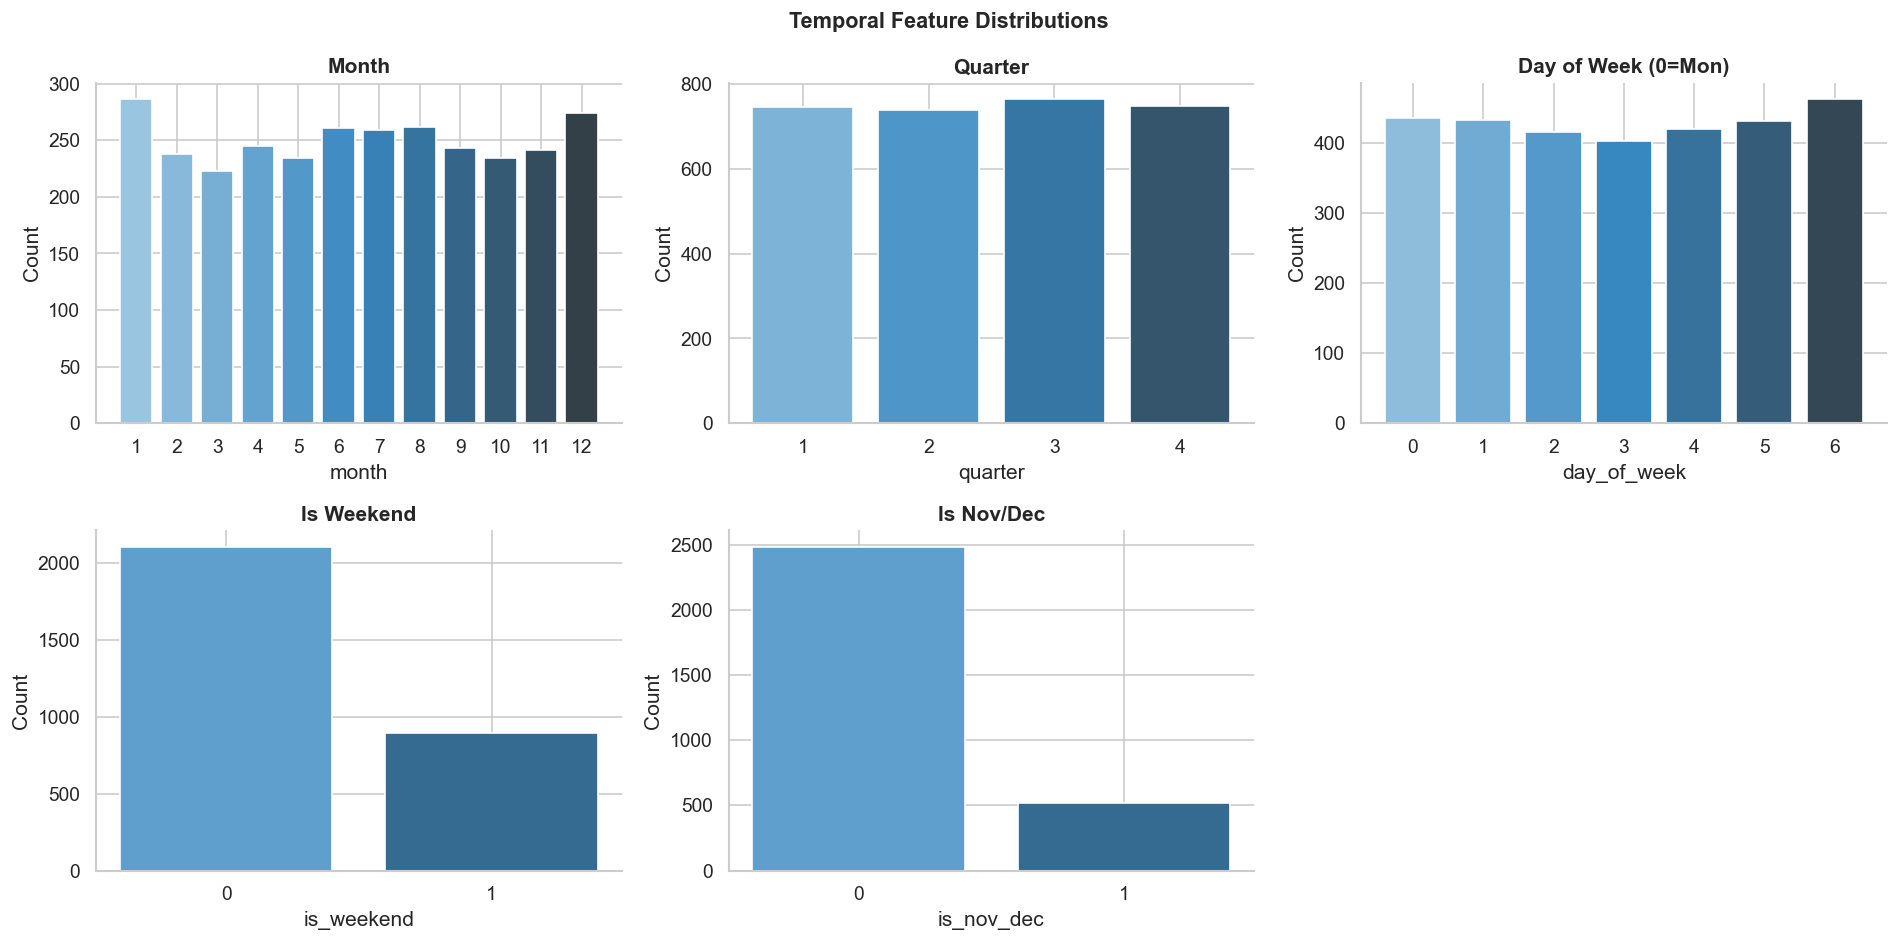

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle("Temporal Feature Distributions", fontsize=13, fontweight="bold")

temporal_plots = [
    ("month",       "Month",             False),
    ("quarter",     "Quarter",           False),
    ("day_of_week", "Day of Week (0=Mon)",False),
    ("is_weekend",  "Is Weekend",        True),
    ("is_nov_dec",  "Is Nov/Dec",        True),
]
for ax, (col, label, is_binary) in zip(axes.flat, temporal_plots):
    vc = df[col].value_counts().sort_index()
    bars = ax.bar(vc.index.astype(str), vc.values,
                  color=sns.color_palette("Blues_d", len(vc)), edgecolor="white")
    ax.set_title(label, fontweight="bold")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")

axes.flat[-1].set_visible(False)
plt.tight_layout()
plt.savefig("../data/fig_feat_temporal.png", bbox_inches="tight")
plt.show()


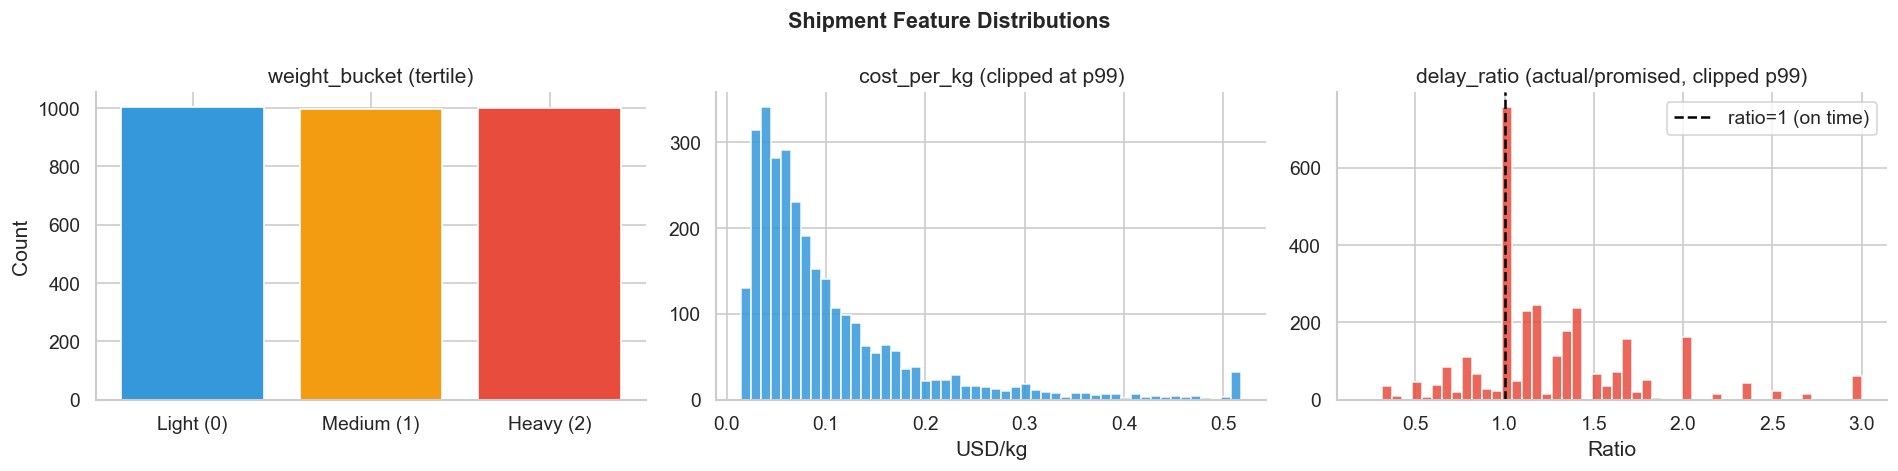

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Shipment Feature Distributions", fontsize=13, fontweight="bold")

# Weight bucket
ax = axes[0]
vc = df["weight_bucket"].value_counts().sort_index()
ax.bar(["Light (0)", "Medium (1)", "Heavy (2)"], vc.values,
       color=["#3498db","#f39c12","#e74c3c"], edgecolor="white")
ax.set_title("weight_bucket (tertile)"); ax.set_ylabel("Count")

# cost_per_kg
ax = axes[1]
ax.hist(df["cost_per_kg"].clip(upper=df["cost_per_kg"].quantile(0.99)),
        bins=50, color="#3498db", edgecolor="white", alpha=0.85)
ax.set_title("cost_per_kg (clipped at p99)"); ax.set_xlabel("USD/kg")

# delay_ratio
ax = axes[2]
ax.hist(df["delay_ratio"].clip(upper=df["delay_ratio"].quantile(0.99)),
        bins=50, color="#e74c3c", edgecolor="white", alpha=0.85)
ax.axvline(1.0, color="black", lw=1.5, ls="--", label="ratio=1 (on time)")
ax.set_title("delay_ratio (actual/promised, clipped p99)")
ax.set_xlabel("Ratio"); ax.legend()

plt.tight_layout()
plt.savefig("../data/fig_feat_shipment.png", bbox_inches="tight")
plt.show()


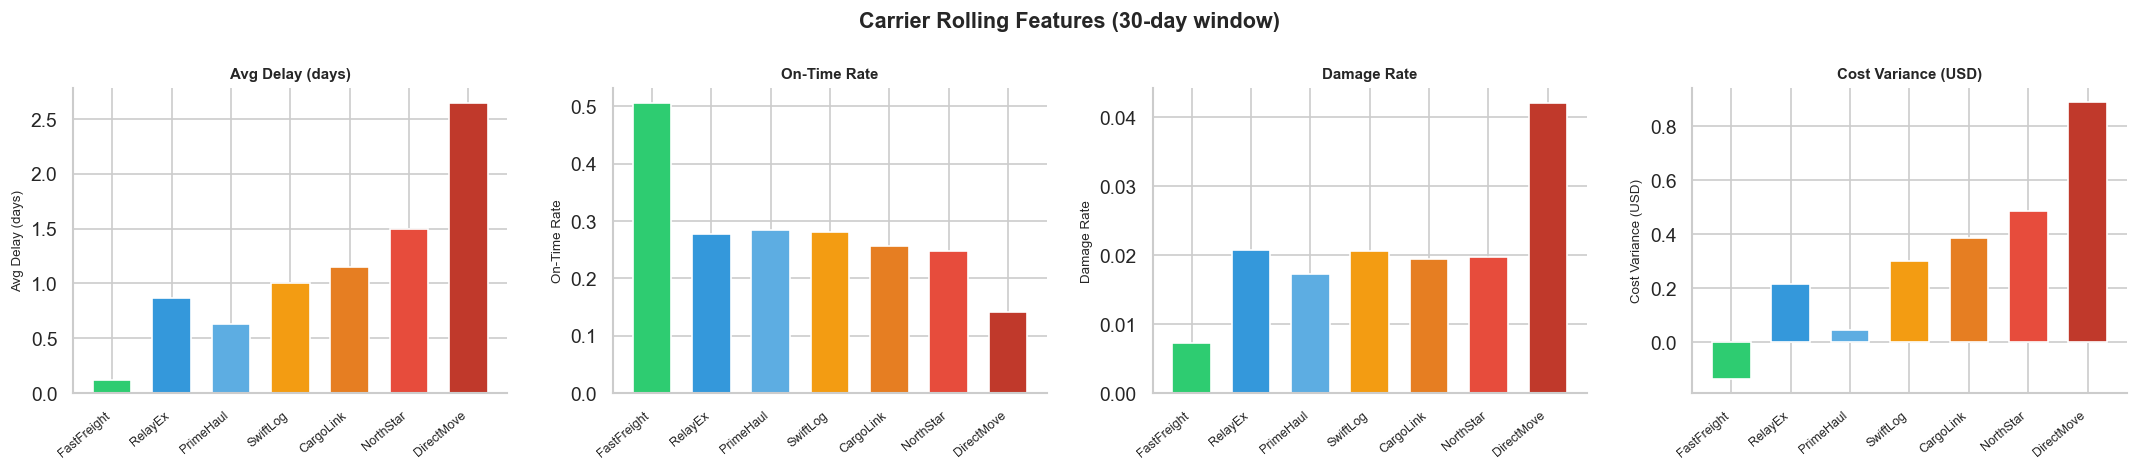

Rolling feature means by carrier:
             rolling_avg_delay  rolling_on_time_rate  rolling_damage_rate  rolling_cost_variance
carrier                                                                                         
FastFreight             0.1157                0.5064               0.0072                -0.1384
RelayEx                 0.8677                0.2778               0.0208                 0.2133
PrimeHaul               0.6252                0.2849               0.0173                 0.0447
SwiftLog                1.0037                0.2806               0.0205                 0.2995
CargoLink               1.1541                0.2565               0.0194                 0.3833
NorthStar               1.4939                0.2475               0.0198                 0.4840
DirectMove              2.6483                0.1406               0.0421                 0.8886


In [6]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle("Carrier Rolling Features (30-day window)", fontsize=13, fontweight="bold")

CARRIERS_ORDER = ["FastFreight","RelayEx","PrimeHaul","SwiftLog","CargoLink","NorthStar","DirectMove"]
CARRIER_COLORS = {
    "FastFreight":"#2ecc71","RelayEx":"#3498db","PrimeHaul":"#5dade2",
    "SwiftLog":"#f39c12","CargoLink":"#e67e22","NorthStar":"#e74c3c","DirectMove":"#c0392b",
}

rolling_cols = ["rolling_avg_delay","rolling_on_time_rate","rolling_damage_rate","rolling_cost_variance"]
rolling_labels = ["Avg Delay (days)","On-Time Rate","Damage Rate","Cost Variance (USD)"]

for ax, col, label in zip(axes, rolling_cols, rolling_labels):
    carrier_means = df.groupby("carrier")[col].mean().reindex(CARRIERS_ORDER)
    colors = [CARRIER_COLORS[c] for c in CARRIERS_ORDER]
    bars = ax.bar(CARRIERS_ORDER, carrier_means, color=colors, edgecolor="white", width=0.65)
    ax.set_title(label, fontweight="bold", fontsize=9)
    ax.set_xticklabels(CARRIERS_ORDER, rotation=40, ha="right", fontsize=7.5)
    ax.set_ylabel(label, fontsize=8)

plt.tight_layout()
plt.savefig("../data/fig_feat_rolling.png", bbox_inches="tight")
plt.show()

print("Rolling feature means by carrier:")
print(df.groupby("carrier")[rolling_cols].mean().reindex(CARRIERS_ORDER).round(4).to_string())


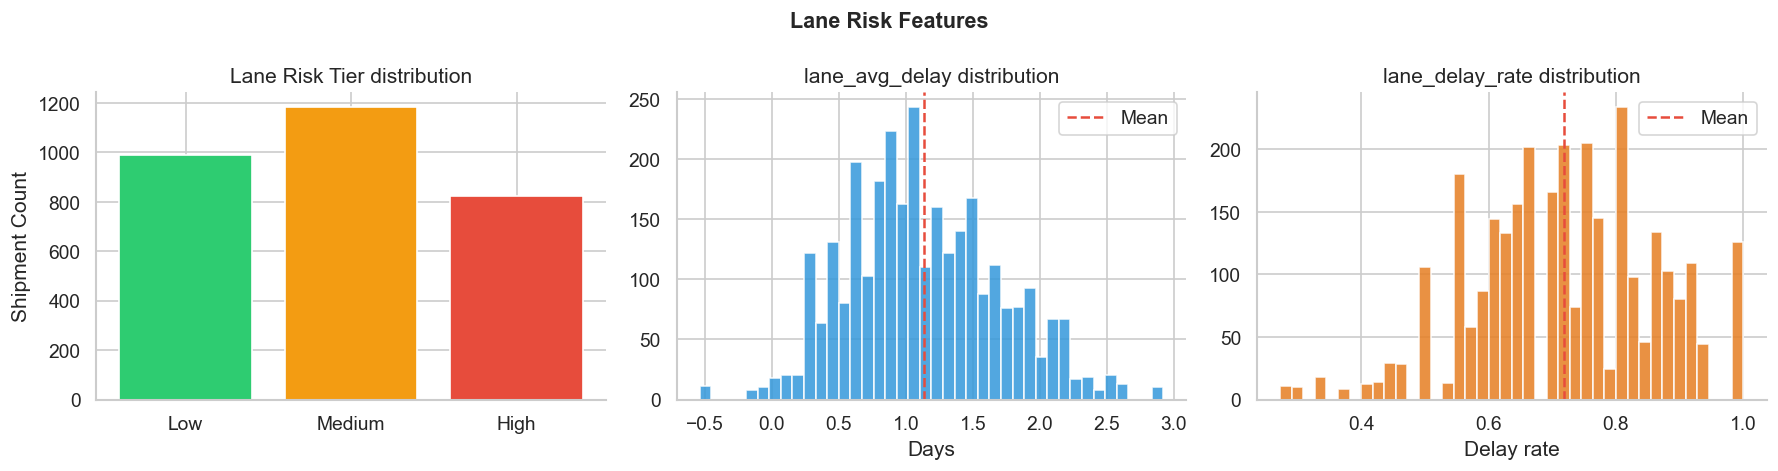

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Lane Risk Features", fontsize=13, fontweight="bold")

tier_map = {0:"Low",1:"Medium",2:"High"}
tier_colors = {0:"#2ecc71",1:"#f39c12",2:"#e74c3c"}

ax = axes[0]
vc = df["lane_risk_numeric"].value_counts().sort_index()
ax.bar([tier_map[i] for i in vc.index], vc.values,
       color=[tier_colors[i] for i in vc.index], edgecolor="white")
ax.set_title("Lane Risk Tier distribution"); ax.set_ylabel("Shipment Count")

ax = axes[1]
ax.hist(df["lane_avg_delay"], bins=40, color="#3498db", edgecolor="white", alpha=0.85)
ax.axvline(df["lane_avg_delay"].mean(), color="#e74c3c", lw=1.5, ls="--", label="Mean")
ax.set_title("lane_avg_delay distribution"); ax.set_xlabel("Days"); ax.legend()

ax = axes[2]
ax.hist(df["lane_delay_rate"], bins=40, color="#e67e22", edgecolor="white", alpha=0.85)
ax.axvline(df["lane_delay_rate"].mean(), color="#e74c3c", lw=1.5, ls="--", label="Mean")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:,.0f}"))
ax.set_title("lane_delay_rate distribution"); ax.set_xlabel("Delay rate"); ax.legend()

plt.tight_layout()
plt.savefig("../data/fig_feat_lane.png", bbox_inches="tight")
plt.show()


---
## 3. Feature Correlation with Target Variables

We compute Pearson correlations between each feature and the two primary targets:
- **`is_delayed`** (binary classification target)
- **`cost_variance_usd`** (regression target)

Features are sorted by absolute correlation. Higher bars = stronger predictive signal.


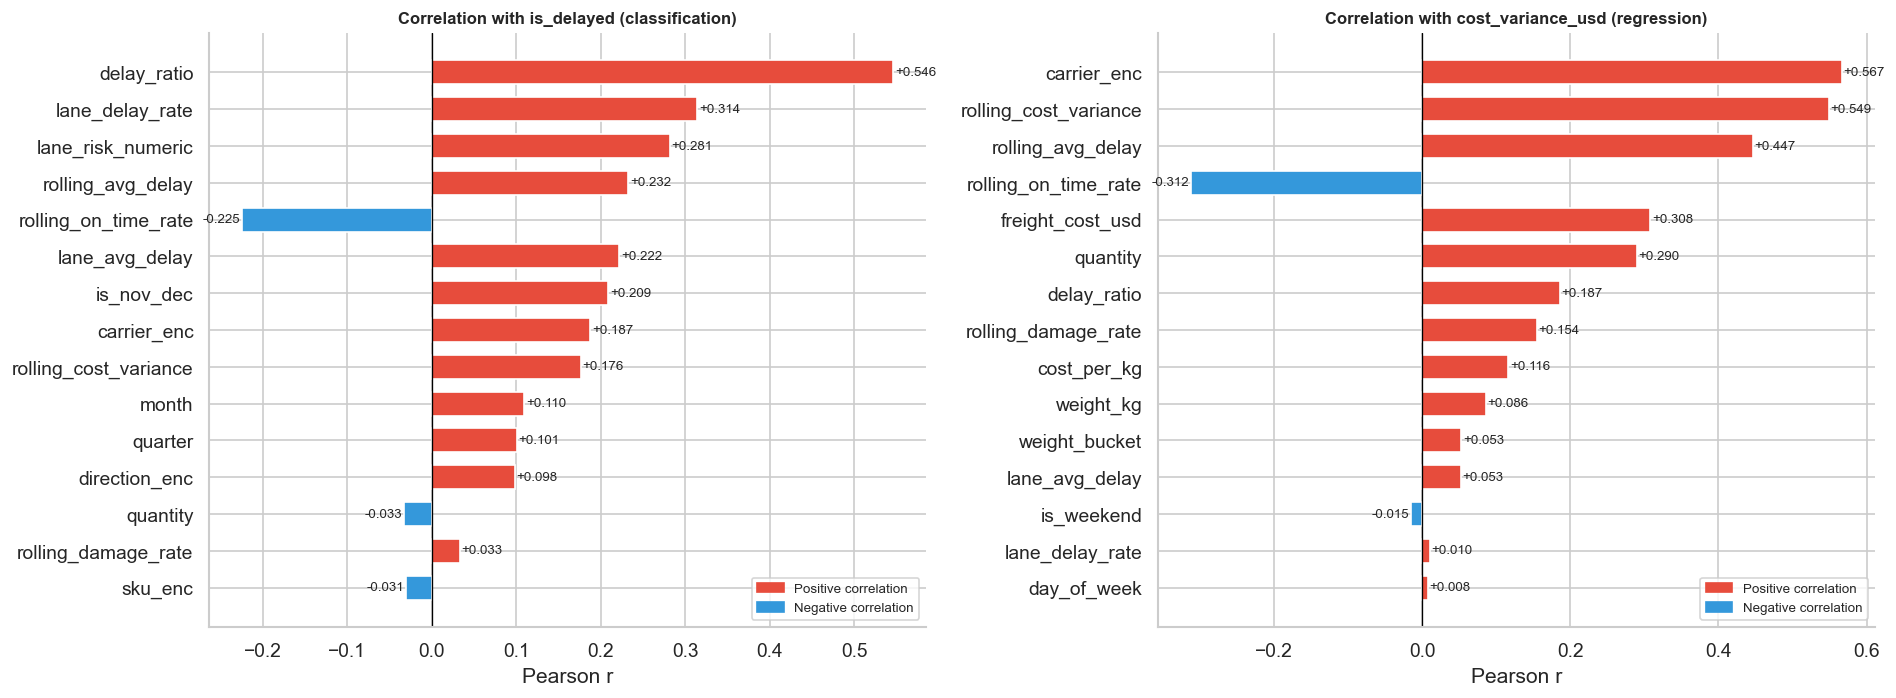

In [8]:
# Encode categorical cols for correlation analysis
df_enc = df.copy()
df_enc["direction_enc"] = (df_enc["direction"] == "inbound").astype(int)

CARRIER_RANK = {c: i for i, c in enumerate(
    ["FastFreight","PrimeHaul","RelayEx","SwiftLog","CargoLink","NorthStar","DirectMove"]
)}
SKU_RANK = {s: i for i, s in enumerate(df_enc["sku_category"].unique())}

df_enc["carrier_enc"]  = df_enc["carrier"].map(CARRIER_RANK)
df_enc["sku_enc"]      = df_enc["sku_category"].map(SKU_RANK)

ALL_FEATURE_COLS = fe.feature_cols + ["direction_enc", "carrier_enc", "sku_enc",
                                       "weight_kg", "quantity",
                                       "promised_lead_days", "freight_cost_usd"]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, target, title in [
    (axes[0], "is_delayed",        "Correlation with is_delayed (classification)"),
    (axes[1], "cost_variance_usd", "Correlation with cost_variance_usd (regression)"),
]:
    corr = (
        df_enc[ALL_FEATURE_COLS + [target]]
        .corr()[target]
        .drop(target)
        .dropna()
    )
    top15 = corr.reindex(corr.abs().sort_values(ascending=False).index).head(15)

    colors = ["#e74c3c" if v > 0 else "#3498db" for v in top15.values]
    bars = ax.barh(top15.index[::-1], top15.values[::-1], color=colors[::-1],
                   edgecolor="white", height=0.65)
    ax.axvline(0, color="black", lw=0.8)
    ax.set_xlabel("Pearson r")
    ax.set_title(title, fontweight="bold", fontsize=10)
    for bar, val in zip(bars, top15.values[::-1]):
        ax.text(val + (0.002 if val >= 0 else -0.002),
                bar.get_y() + bar.get_height()/2,
                f"{val:+.3f}", va="center", ha="left" if val >= 0 else "right", fontsize=8)

    red_p  = mpatches.Patch(color="#e74c3c", label="Positive correlation")
    blue_p = mpatches.Patch(color="#3498db", label="Negative correlation")
    ax.legend(handles=[red_p, blue_p], fontsize=8, loc="lower right")

plt.tight_layout()
plt.savefig("../data/fig_feat_target_corr.png", bbox_inches="tight")
plt.show()


In [9]:
# Print full correlation table for both targets
corr_table = (
    df_enc[ALL_FEATURE_COLS + ["is_delayed", "cost_variance_usd"]]
    .corr()[["is_delayed", "cost_variance_usd"]]
    .drop(["is_delayed", "cost_variance_usd"], errors="ignore")
    .dropna()
    .assign(abs_is_delayed=lambda x: x["is_delayed"].abs())
    .sort_values("abs_is_delayed", ascending=False)
    .drop(columns=["abs_is_delayed"])
)
print("Feature correlations with targets (sorted by |r| with is_delayed):")
print(corr_table.round(4).to_string())


Feature correlations with targets (sorted by |r| with is_delayed):
                       is_delayed  cost_variance_usd
delay_ratio                0.5461             0.1865
lane_delay_rate            0.3142             0.0102
lane_risk_numeric          0.2814             0.0014
rolling_avg_delay          0.2324             0.4469
rolling_on_time_rate      -0.2246            -0.3122
lane_avg_delay             0.2218             0.0529
is_nov_dec                 0.2089            -0.0070
carrier_enc                0.1875             0.5668
rolling_cost_variance      0.1764             0.5491
month                      0.1096            -0.0074
quarter                    0.1006             0.0046
direction_enc              0.0979             0.0075
quantity                  -0.0332             0.2902
rolling_damage_rate        0.0331             0.1545
sku_enc                   -0.0308             0.0080
freight_cost_usd          -0.0292             0.3083
cost_per_kg               -0.024

---
## 4. Multicollinearity Check

High correlation between features (|r| > 0.85) can destabilise linear models
and bloat tree-based models with redundant splits.  We flag any such pairs here
so that feature selection or dimensionality reduction can be applied if needed.


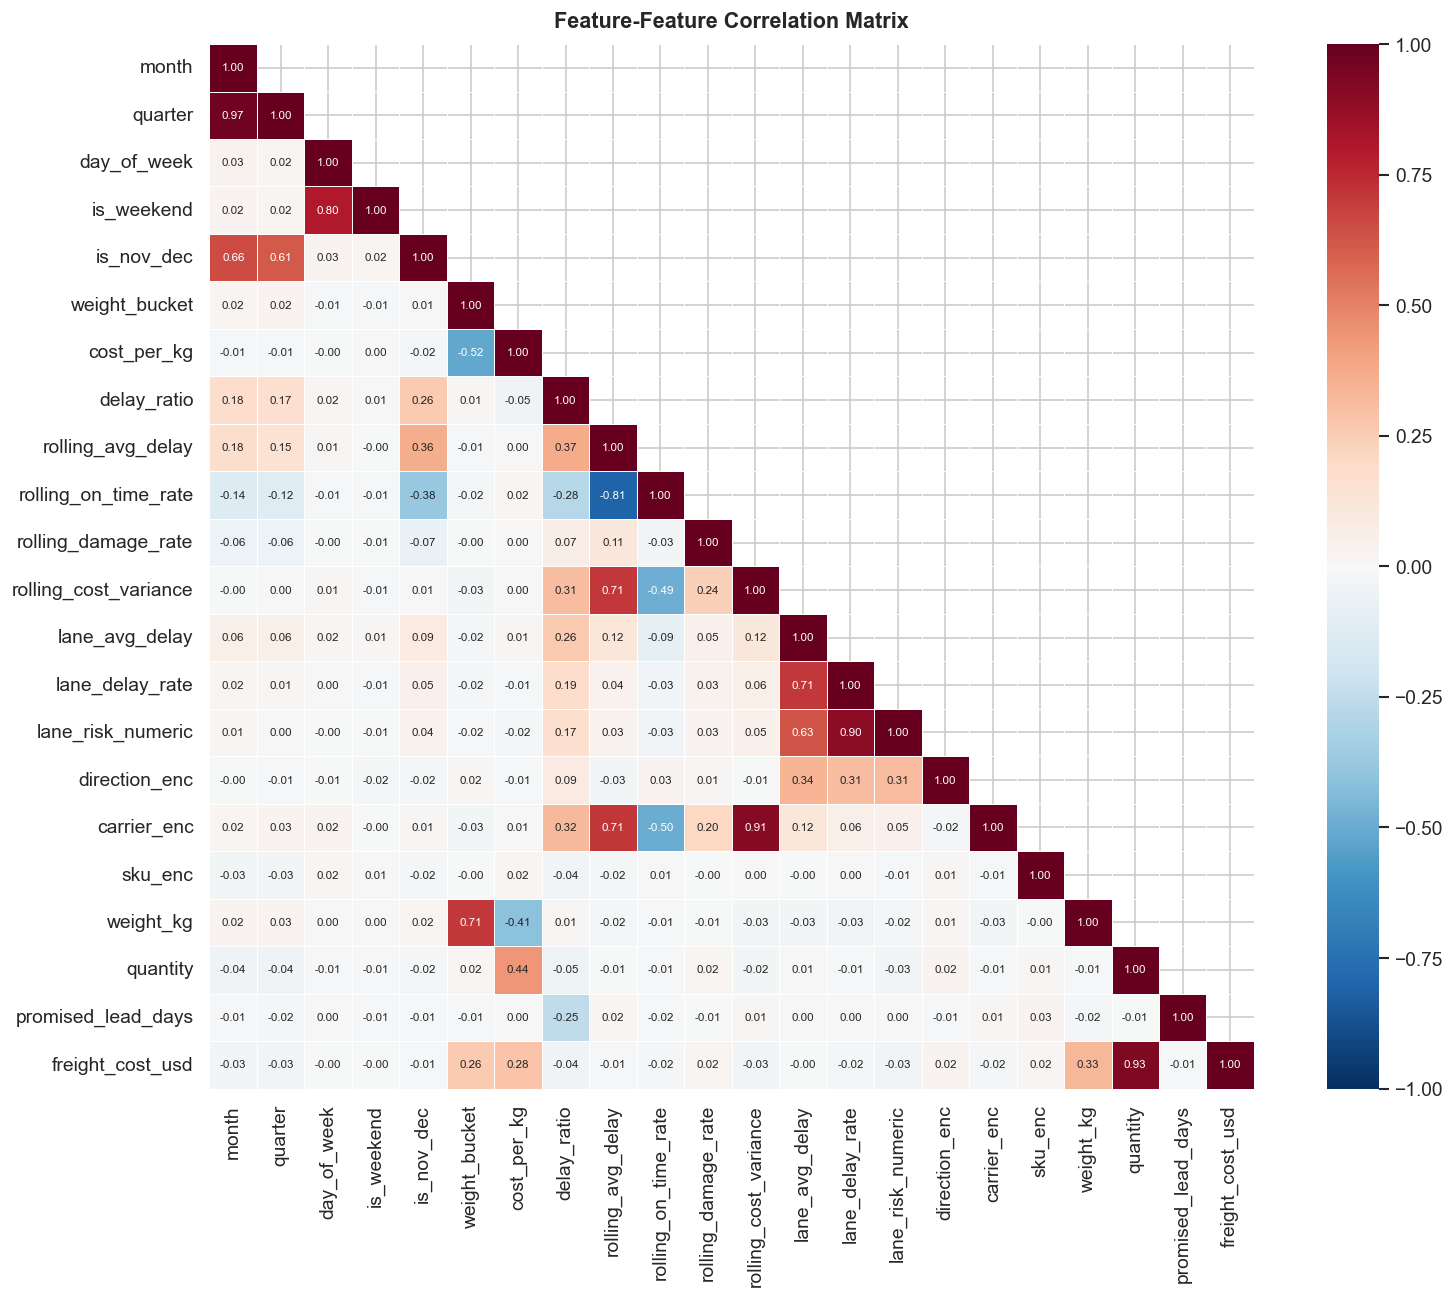

In [10]:
feat_corr = df_enc[ALL_FEATURE_COLS].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(feat_corr, dtype=bool), k=1)
sns.heatmap(
    feat_corr, mask=mask,
    annot=True, fmt=".2f",
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    linewidths=0.4, linecolor="white",
    square=True, ax=ax,
    annot_kws={"size": 7},
)
ax.set_title("Feature-Feature Correlation Matrix", fontsize=13, fontweight="bold", pad=10)
plt.tight_layout()
plt.savefig("../data/fig_feat_multicollinearity.png", bbox_inches="tight")
plt.show()


In [11]:
# Find pairs with |r| > 0.85
threshold = 0.85
lower = feat_corr.where(np.tril(np.ones(feat_corr.shape), k=-1).astype(bool))
high_corr = (
    lower.stack()
    .reset_index()
    .rename(columns={"level_0": "feature_a", "level_1": "feature_b", 0: "r"})
    .assign(abs_r=lambda x: x["r"].abs())
    .query("abs_r > @threshold")
    .sort_values("abs_r", ascending=False)
    .reset_index(drop=True)
)

if high_corr.empty:
    print(f"No feature pairs exceed |r| = {threshold}. Multicollinearity is not a concern.")
else:
    print(f"Feature pairs with |r| > {threshold} — consider dropping one from each pair:")
    print()
    for _, row in high_corr.iterrows():
        print(f"  {row['feature_a']:<30s}  <->  {row['feature_b']:<30s}  r = {row['r']:+.4f}")


Feature pairs with |r| > 0.85 — consider dropping one from each pair:

  quarter                         <->  month                           r = +0.9720
  freight_cost_usd                <->  quantity                        r = +0.9319
  carrier_enc                     <->  rolling_cost_variance           r = +0.9109
  lane_risk_numeric               <->  lane_delay_rate                 r = +0.8976


---
## 5. Final Feature Matrix

Summary of the dataset that will be handed to the modelling stage.


In [12]:
print("=" * 60)
print("FINAL FEATURE MATRIX SUMMARY")
print("=" * 60)
print(f"  Rows            : {df.shape[0]:,}")
print(f"  Total columns   : {df.shape[1]}")
print(f"  Feature columns : {len(fe.feature_cols)}")
print(f"  Target columns  : {len(fe.target_cols)}  {fe.target_cols}")
print(f"  Identifier cols : shipment_id, date, carrier, origin, destination, ...")
print()
print("Feature columns:")
for c in fe.feature_cols:
    print(f"  {c:<30s}  "
          f"min={df[c].min():.3f}  max={df[c].max():.3f}  "
          f"mean={df[c].mean():.3f}")


FINAL FEATURE MATRIX SUMMARY
  Rows            : 3,000
  Total columns   : 33
  Feature columns : 15
  Target columns  : 3  ['is_delayed', 'delay_days', 'cost_variance_usd']
  Identifier cols : shipment_id, date, carrier, origin, destination, ...

Feature columns:
  month                           min=1.000  max=12.000  mean=6.507
  quarter                         min=1.000  max=4.000  mean=2.505
  day_of_week                     min=0.000  max=6.000  mean=3.027
  is_weekend                      min=0.000  max=1.000  mean=0.298
  is_nov_dec                      min=0.000  max=1.000  mean=0.172
  weight_bucket                   min=0.000  max=2.000  mean=0.999
  cost_per_kg                     min=0.015  max=2.157  mean=0.104
  delay_ratio                     min=0.200  max=4.500  mean=1.276
  rolling_avg_delay               min=-0.700  max=4.850  mean=1.108
  rolling_on_time_rate            min=0.000  max=1.000  mean=0.286
  rolling_damage_rate             min=0.000  max=0.222  mean=0.

In [13]:
print("Sample of 5 rows (feature columns only):")
sample = df[fe.feature_cols + fe.target_cols].sample(5, random_state=42).reset_index(drop=True)
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)
print(sample.round(3).to_string())


Sample of 5 rows (feature columns only):
   month  quarter  day_of_week  is_weekend  is_nov_dec  weight_bucket  cost_per_kg  delay_ratio  rolling_avg_delay  rolling_on_time_rate  rolling_damage_rate  rolling_cost_variance  lane_avg_delay  lane_delay_rate  lane_risk_numeric  is_delayed  delay_days  cost_variance_usd
0      2        1            5           1           0              1        0.057        1.143              0.845                 0.227                0.000                  0.159           0.967            0.778                  1           1         1.0               0.17
1     10        4            1           0           0              2        0.038        1.286              0.590                 0.333                0.000                  0.154           0.993            0.867                  2           1         1.5               0.31
2      2        1            3           0           0              0        0.106        0.667             -0.079                 

---
## 6. Save Engineered Dataset

The full DataFrame (original columns + all features) is saved to
`data/shipments_featured.csv` for use in downstream modelling notebooks.


In [14]:
out_path = DATA / "shipments_featured.csv"
df.to_csv(out_path, index=False)

saved = pd.read_csv(out_path)
print(f"Saved: {out_path}")
print(f"Shape on reload: {saved.shape}")
print(f"Columns: {list(saved.columns)}")


Saved: ..\data\shipments_featured.csv
Shape on reload: (3000, 33)
Columns: ['shipment_id', 'date', 'direction', 'carrier', 'origin', 'destination', 'lane_id', 'sku_category', 'weight_kg', 'quantity', 'promised_lead_days', 'actual_lead_days', 'delay_days', 'is_delayed', 'freight_cost_usd', 'invoiced_cost_usd', 'cost_variance_usd', 'damage_flag', 'month', 'day_of_week', 'is_weekend', 'is_nov_dec', 'quarter', 'weight_bucket', 'cost_per_kg', 'delay_ratio', 'rolling_avg_delay', 'rolling_on_time_rate', 'rolling_damage_rate', 'rolling_cost_variance', 'lane_avg_delay', 'lane_delay_rate', 'lane_risk_numeric']
